# Reto 03 - Transfer Learning

## Clasificación de productos de una tienda de abarrotes a partir de fotografías

> **Fuente del problema:** [Grocery Store Dataset](https://www.kaggle.com/datasets/validmodel/grocery-store-dataset/data)
> publicado en **Kaggle**, réplica del repositorio original de [Klasson, Zhang y Kjellström](https://github.com/marcusklasson/GroceryStoreDataset),
> presentado en el artículo *"A Hierarchical Grocery Store Image Dataset with Visual and Semantic Labels"* (**WACV 2019**).

### El problema

El conjunto contiene **5,125 fotografías naturales** de frutas, verduras y productos refrigerados envasados, tomadas con la cámara de un teléfono celular dentro de tiendas de abarrotes de Suecia. A diferencia de las imágenes de catálogo, son fotos "en el mundo real": iluminación variable, fondos con anaqueles y otros productos, oclusiones, distintos ángulos y distancias, y varios artículos de la misma clase apilados en una sola toma.

Las etiquetas están organizadas de forma **jerárquica en dos niveles**:

- **81 clases finas** (*fine-grained*): la variedad concreta del producto, por ejemplo `Golden-Delicious`, `Granny-Smith`, `Pink-Lady` o `Royal-Gala`.
- **43 clases gruesas** (*coarse-grained*): la categoría del producto, por ejemplo `Apple`, que agrupa a las cuatro variedades anteriores.

A su vez, esas categorías se agrupan en tres departamentos: **Fruit**, **Vegetables** y **Packages** (lácteos y jugos envasados).

La dificultad central es que muchas clases finas son **visualmente casi idénticas** —dos variedades de manzana roja, dos marcas de yogur en envases del mismo color— y el número de ejemplos por clase es pequeño (decenas, no miles). Entrenar una red convolucional profunda desde cero con tan pocas imágenes lleva casi inevitablemente a **sobreajuste**. Este es justamente el escenario donde el **transfer learning** resulta natural: reutilizar las representaciones visuales que una red ya aprendió sobre un corpus masivo (ImageNet) y adaptarlas al dominio de los abarrotes.

### Objetivo

1. Construir una línea base entrenando una **CNN desde cero** sobre el conjunto y medir su desempeño y su grado de sobreajuste.
2. Aplicar **transfer learning** con una red preentrenada en ImageNet (p. ej. `MobileNetV2`, `ResNet50` o `EfficientNet`).
3. analizar el efecto del **aumento de datos** (*data augmentation*) sobre la brecha entre entrenamiento y validación.
4. Evaluar el problema en sus **dos niveles de granularidad** (81 clases finas y 43 gruesas) y revisar en la matriz de confusión si los errores del modelo se concentran dentro de una misma categoría gruesa.

### Estructura de los datos

El archivo `grocery-store-dataset.zip` se descomprime en `GroceryStoreDataset/`, con la siguiente organización:

| Ruta | Contenido |
|---|---|
| `dataset/train/`, `dataset/val/`, `dataset/test/` | Imágenes naturales en carpetas anidadas `Departamento/ClaseGruesa/ClaseFina/` |
| `dataset/classes.csv` | Tabla que mapea cada clase fina a su `Class ID`, su clase gruesa y su `Coarse Class ID` |
| `dataset/iconic-images-and-descriptions/` | Una **imagen icónica** (foto de catálogo sobre fondo blanco) y una **descripción en texto** por clase |
| `sample_images/` | Ejemplos ilustrativos de imágenes naturales e icónicas |

In [1]:
import ctypes
import glob
import os
import site
import sys


def preload_cuda_libraries(verbose: bool = True):
    """Equivalente a exportar LD_LIBRARY_PATH, pero ejecutable dentro del notebook."""
    if sys.platform != "linux":
        if verbose:
            print("No es Linux: no hay nada que precargar.")

        return []

    bases = list(getattr(site, "getsitepackages", list)())
    bases.append(site.getusersitepackages())
    bases.append(
        os.path.join(
            sys.prefix,
            "lib",
            f"python{sys.version_info.major}.{sys.version_info.minor}",
            "site-packages",
        )
    )

    lib_dirs = sorted(
        {
            d
            for base in bases
            for d in glob.glob(os.path.join(base, "nvidia", "*", "lib"))
        }
    )

    if not lib_dirs:
        if verbose:
            print("No se encontraron paquetes nvidia-*: instala tensorflow[and-cuda].")

        return []

    # Para los procesos hijos (ptxas y demás herramientas que invoca XLA).
    os.environ["LD_LIBRARY_PATH"] = ":".join(
        lib_dirs + [os.environ.get("LD_LIBRARY_PATH", "")]
    ).strip(":")

    pendientes = sorted(
        {p for d in lib_dirs for p in glob.glob(os.path.join(d, "lib*.so*"))}
    )
    cargadas = []

    # Varias pasadas: unas bibliotecas dependen de otras y el orden del glob no lo respeta.
    while pendientes:
        fallidas = []
        for ruta in pendientes:
            try:
                ctypes.CDLL(ruta, mode=ctypes.RTLD_GLOBAL)
                cargadas.append(ruta)
            except OSError:
                fallidas.append(ruta)

        if len(fallidas) == len(pendientes):
            break

        pendientes = fallidas

    if verbose:
        print(f"Directorios: {len(lib_dirs)} | bibliotecas cargadas: {len(cargadas)}")


preload_cuda_libraries()

Directorios: 11 | bibliotecas cargadas: 31


In [2]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")


import keras
import keras_hub
import pathlib
import logging
import warnings


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

warnings.filterwarnings("ignore", category=UserWarning)

AUTOTUNE = tf.data.AUTOTUNE

print(
    "Keras:",
    keras.__version__,
    "| backend:",
    keras.backend.backend(),
    "| GPUs:",
    tf.config.list_physical_devices("GPU"),
)

Keras: 3.15.1 | backend: tensorflow | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
class GrocerySequenceDataset:
    def __init__(
        self,
        path: str,
        image_size: tuple[int, int] = (384, 384),
    ) -> None:
        self.pwd = pathlib.Path(path).parent
        self.data = pd.read_csv(path, header=None)
        self.image_size = image_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if not (0 <= idx < len(self.data)):
            raise IndexError()

        # load image
        filename = self.data[0][idx]
        image = keras.utils.load_img(os.path.join(self.pwd, filename))
        image = tf.image.resize(image, self.image_size, method="bilinear")
        array = keras.utils.img_to_array(image)

        # load class
        finegrain_class_id = np.int32(self.data[1][idx])
        coarse_class_id = np.int32(self.data[2][idx])

        return array, finegrain_class_id, coarse_class_id

In [4]:
def load_classes(path: str):
    classes = pd.read_csv(path, skipinitialspace=True)
    classes.columns = [
        "class_name",
        "class_id",
        "coarse_class_name",
        "coarse_class_id",
        "iconic_path",
        "description_path",
    ]

    return classes


In [5]:
train_seq = GrocerySequenceDataset(
    "../data/grocery-store/GroceryStoreDataset/dataset/train.txt"
)

val_seq = GrocerySequenceDataset(
    "../data/grocery-store/GroceryStoreDataset/dataset/val.txt"
)

test_seq = GrocerySequenceDataset(
    "../data/grocery-store/GroceryStoreDataset/dataset/test.txt"
)

classes = load_classes("../data/grocery-store/GroceryStoreDataset/dataset/classes.csv")

print(
    "train:",
    len(train_seq.data),
    "| val:",
    len(val_seq.data),
    "| test:",
    len(test_seq.data),
)

train: 2640 | val: 296 | test: 2485


In [6]:
def plot_image_grid(
    source,
    indices=None,
    n: int = 16,
    cols: int = 4,
    classes: pd.DataFrame = None,
    figsize_scale: float = 3.0,
    seed: int = None,
):
    if isinstance(source, tuple):
        images, fine_ids, coarse_ids = source
        total = len(np.asarray(images))
        titulo = "Imágenes"
    else:
        rng = np.random.default_rng(seed)
        total = len(source)
        if indices is None:
            indices = rng.permutation(total)[: min(n, total)]
        indices = np.ravel(indices).astype(int)

        muestras = [source[int(i)] for i in indices]
        images = np.stack([m[0] for m in muestras])
        fine_ids = np.array([m[1] for m in muestras])
        coarse_ids = np.array([m[2] for m in muestras])
        titulo = f"{len(indices)} imágenes de {total}"

    images = np.asarray(images)
    fine_ids = np.ravel(fine_ids)
    coarse_ids = np.ravel(coarse_ids)

    n = min(n, len(images))
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))

    fine_names, coarse_names = {}, {}
    if classes is not None:
        fine_names = dict(zip(classes.class_id, classes.class_name))
        coarse_names = dict(zip(classes.coarse_class_id, classes.coarse_class_name))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale, rows * figsize_scale * 1.15),
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, image, fine_id, coarse_id in zip(
        axes, images[:n], fine_ids[:n], coarse_ids[:n]
    ):
        ax.imshow(image.astype("uint8"))
        ax.set_title(
            f"{fine_names.get(int(fine_id), int(fine_id))}\n"
            f"({coarse_names.get(int(coarse_id), int(coarse_id))})",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"{titulo} — {n} de {len(images)} imágenes")
    plt.show()

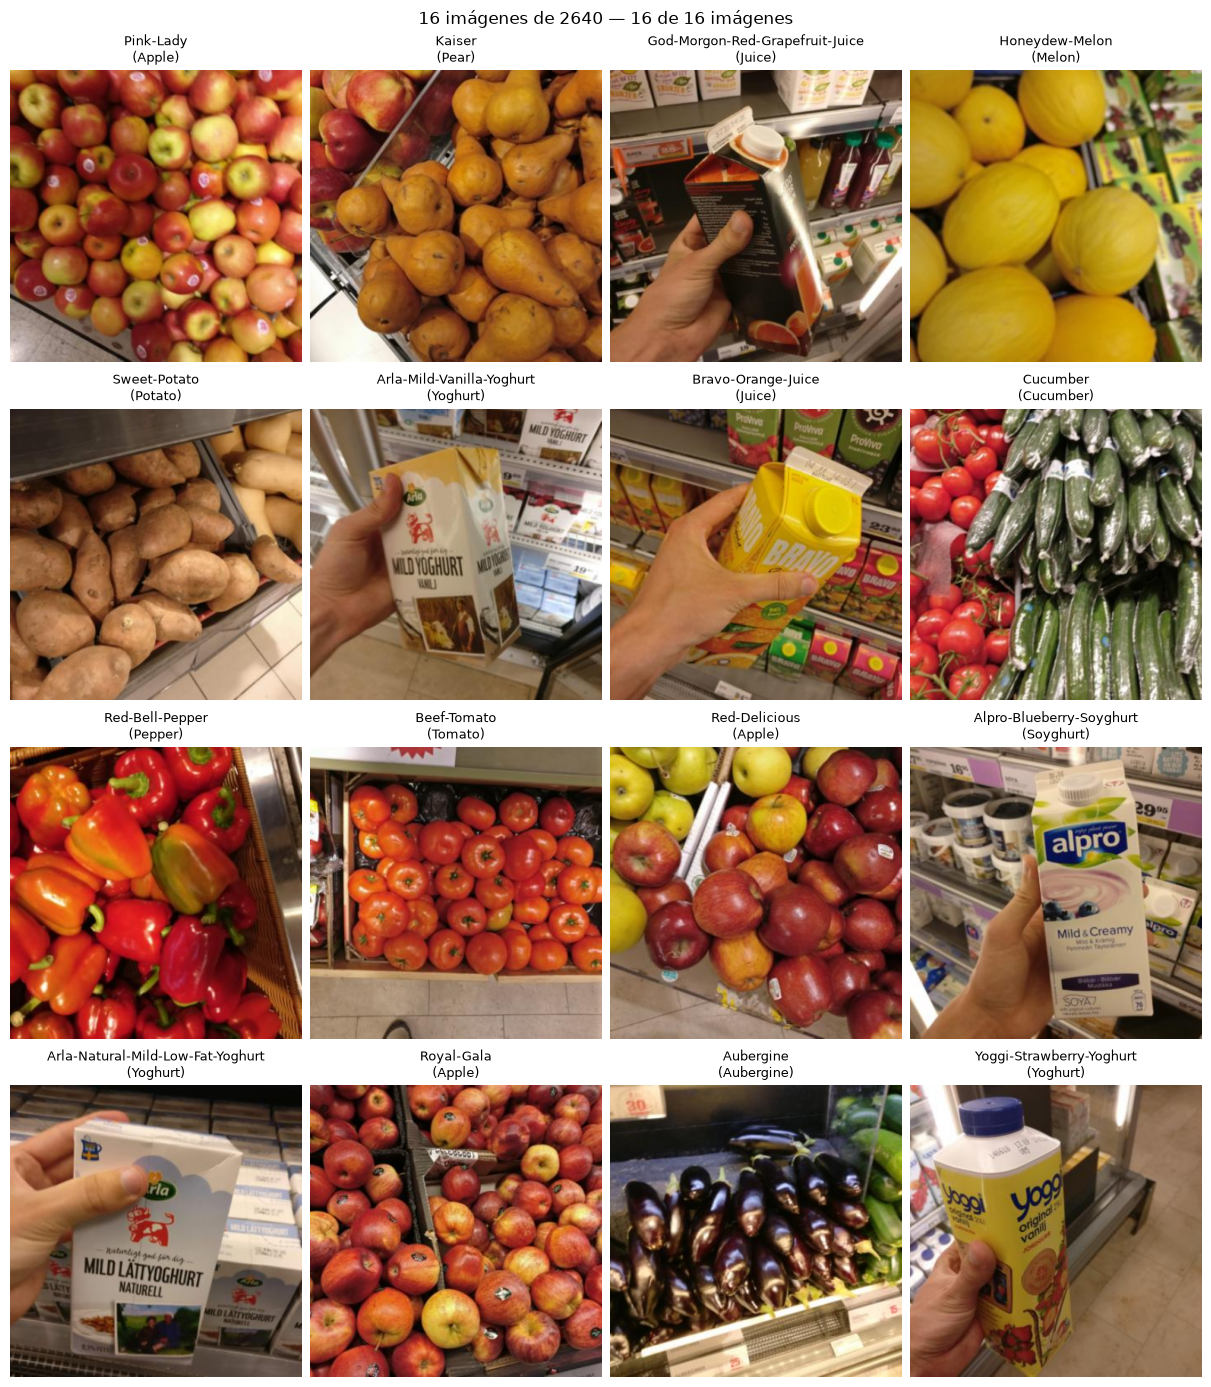

In [7]:
plot_image_grid(train_seq, classes=classes, seed=5)

In [8]:
def plot_class_distribution(
    source,
    classes: pd.DataFrame = None,
    sort: bool = True,
    color: str = "#4A6FA5",
    width: float = 14.0,
    row_height: float = 0.26,
):
    if isinstance(source, tuple):
        batches = [source]
    elif isinstance(source, list):
        batches = source
    else:
        batches = None

    if batches is None:
        ids = (source.data[1].to_numpy(), source.data[2].to_numpy())
        titulo = "Distribución de imágenes por clase"
    else:
        ids = tuple(
            np.concatenate([np.ravel(batch[columna]) for batch in batches])
            for columna in (1, 2)
        )
        titulo = f"Distribución de imágenes por clase en {len(batches)} lote(s)"

    levels = (
        ("fina", "class_id", "class_name"),
        ("gruesa", "coarse_class_id", "coarse_class_name"),
    )

    conteos = []
    for etiquetas, (_, id_column, name_column) in zip(ids, levels):
        counts = pd.Series(etiquetas).value_counts()

        if classes is not None:
            names = dict(zip(classes[id_column], classes[name_column]))
            counts.index = [names.get(int(i), int(i)) for i in counts.index]

        counts = (
            counts.sort_values(ascending=True)
            if sort
            else counts.sort_index(ascending=False)
        )
        conteos.append(counts)

    alto = max(3.0, max(len(c) for c in conteos) * row_height)

    fig, axes = plt.subplots(1, 2, figsize=(width, alto), layout="constrained")

    for ax, counts, (etiqueta, _, _) in zip(axes, conteos, levels):
        bars = ax.barh(
            counts.index.astype(str), counts.to_numpy(), color=color, height=0.75
        )
        ax.bar_label(bars, padding=3, fontsize=8, color="#444444")

        ax.set_xlim(0, counts.max() * 1.12)
        ax.set_xlabel("Número de imágenes")
        ax.set_title(f"Clase {etiqueta} ({len(counts)} clases)")
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(axis="y", visible=False)

    fig.suptitle(f"{titulo} ({int(conteos[0].sum())} imágenes)")
    plt.show()

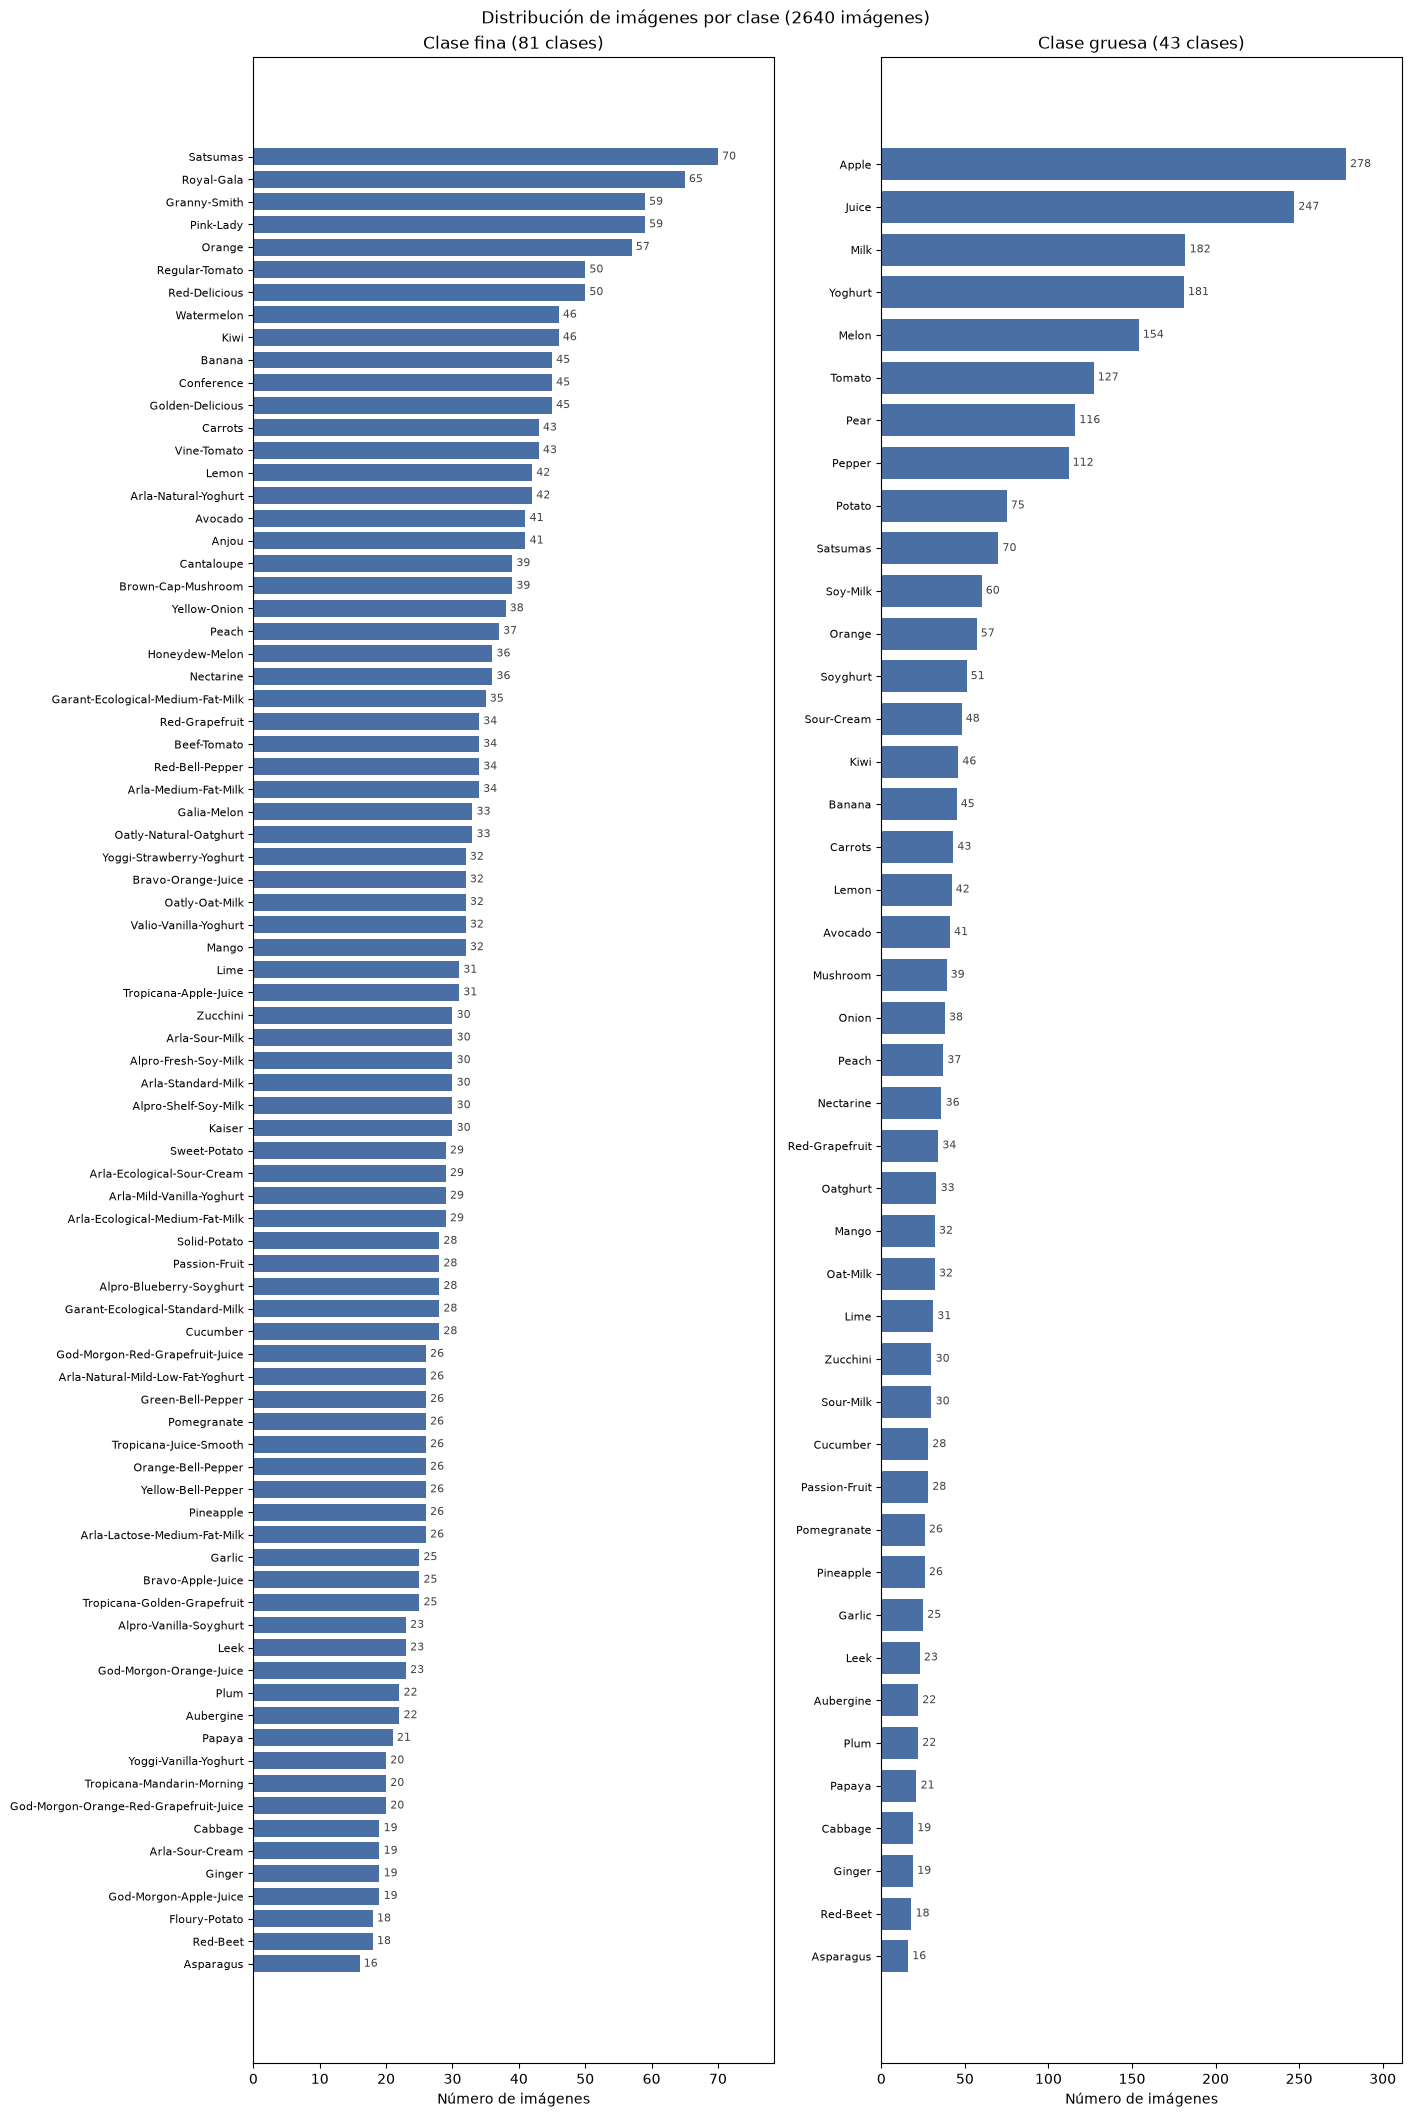

In [9]:
plot_class_distribution(train_seq, classes=classes)

In [10]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype="float32") * 255.0
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype="float32") * 255.0


def preprocess(images):
    images = tf.cast(images, tf.float32)

    return (images - IMAGENET_MEAN) / IMAGENET_STD

In [11]:
def to_tf_dataset(
    sequence: "GrocerySequenceDataset",
    labels: str = "fine",
    batch_size: int = 32,
    one_hot: bool = True,
    fine_classes: int = 81,
    coarse_classes: int = 43,
    preprocess=preprocess,
    shuffle: bool = True,
    cache=False,
    seed: int = None,
):
    if labels not in ("fine", "coarse", "both"):
        raise ValueError("labels debe ser 'fine', 'coarse' o 'both'")

    height, width = sequence.image_size

    def codificar(class_id, n_classes):
        class_id = np.int32(class_id)

        if one_hot:
            return keras.utils.to_categorical(
                class_id, num_classes=n_classes
            ).astype("float32")

        return class_id

    def generator():
        for idx in range(len(sequence)):
            image, fine_id, coarse_id = sequence[idx]
            fine_id = codificar(fine_id, fine_classes)
            coarse_id = codificar(coarse_id, coarse_classes)

            if labels == "fine":
                yield image, fine_id
            elif labels == "coarse":
                yield image, coarse_id
            else:
                yield image, (fine_id, coarse_id)

    def spec(n_classes):
        if one_hot:
            return tf.TensorSpec(shape=(n_classes,), dtype=tf.float32)

        return tf.TensorSpec(shape=(), dtype=tf.int32)

    signature = (
        tf.TensorSpec(shape=(height, width, 3), dtype=tf.float32),
        {
            "fine": spec(fine_classes),
            "coarse": spec(coarse_classes),
            "both": (spec(fine_classes), spec(coarse_classes)),
        }[labels],
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=signature)

    if cache is not False:
        ds = ds.cache() if cache is True else ds.cache(str(cache))

    if shuffle:
        ds = ds.shuffle(len(sequence), seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    if preprocess is not None:
        ds = ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)

    return ds.prefetch(AUTOTUNE)

In [12]:
labels = "both"
one_hot = True
batch_size = 32
cache = False

train_ds = to_tf_dataset(
    train_seq, labels=labels, one_hot=one_hot, batch_size=batch_size, cache=cache
)
val_ds = to_tf_dataset(
    val_seq, labels=labels, one_hot=one_hot, batch_size=batch_size, cache=cache
)
test_ds = to_tf_dataset(
    test_seq, labels=labels, one_hot=one_hot, batch_size=batch_size, cache=cache
)

In [13]:
def build_model(
    image_size: tuple[int, int] = (384, 384),
    fine_classes: int = 81,
    coarse_classes: int = 43,
    preset: str = "efficientnet_b4_ra2_imagenet",
    trainable: bool = False,
    dropout: float = 0.2,
):
    backbone = keras_hub.models.EfficientNetBackbone.from_preset(preset)
    backbone.trainable = trainable

    inputs = keras.Input(shape=(*image_size, 3), name="images")

    features = backbone(inputs)
    pooled = keras.layers.GlobalAveragePooling2D(name="pooling")(features)
    pooled = keras.layers.Dropout(dropout, name="dropout")(pooled)

    fine = keras.layers.Dense(fine_classes, activation="softmax", name="fine")(pooled)
    coarse = keras.layers.Dense(coarse_classes, activation="softmax", name="coarse")(
        pooled
    )

    return keras.Model(inputs=inputs, outputs=[fine, coarse], name=f"grocery_{preset}")

In [14]:
model = build_model(trainable=True)

model.summary()

Model: "grocery_efficientnet_b4_ra2_imagenet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 384, 384,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_back… │ (None, 12, 12,    │ 17,673,816 │ images[0][0]      │
│ (EfficientNetBackb… │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling             │ (None, 1792)      │          0 │ efficient_net_ba… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1792)      │          0 │ pooling[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fine (Dense)        │ (None, 81)        │    145,233 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coarse (Dense)      │ (None, 43)        │     77,099 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,896,148 (68.27 MB)

 Trainable params: 17,770,948 (67.79 MB)

 Non-trainable params: 125,200 (489.06 KB)

In [15]:
# Usamos FocalCrossentropy para que no nos pegue tanto el tema del class imbalance
loss_dict = {
    "fine": keras.losses.CategoricalFocalCrossentropy(label_smoothing=0.1),
    "coarse": keras.losses.CategoricalFocalCrossentropy(label_smoothing=0.1),
}


EPOCHS = 30
WARMUP_EPOCHS = 3

# Calculamos la cantidad de total de steps y ubicamos un 10% para warmup del lr
steps_per_epoch = int(np.ceil(len(train_seq) / batch_size))
total_steps = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    warmup_target=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps - warmup_steps,
    alpha=0.01,
)

print(
    f"pasos/época: {steps_per_epoch} | warmup: {warmup_steps} | "
    f"decay: {total_steps - warmup_steps} | total: {total_steps}"
)

RUTA_MODELO = pathlib.Path(f"../models/reto-03-{model.name}.keras")
RUTA_MODELO.parent.mkdir(parents=True, exist_ok=True)


optim_fn = keras.optimizers.Adam(learning_rate=scheduler)  # type: ignore

stop_cb = keras.callbacks.EarlyStopping(patience=3)
best_cb = keras.callbacks.ModelCheckpoint(filepath=RUTA_MODELO, save_best_only=True)


class LearningRateLogger(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        optim = self.model.optimizer
        lr = optim.learning_rate
        if isinstance(lr, keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(optim.iterations)
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(lr))


lr_cb = LearningRateLogger()


model.compile(
    optimizer=optim_fn,
    loss=loss_dict,
    metrics={
        "fine": [tf.metrics.CategoricalAccuracy()],
        "coarse": [tf.metrics.CategoricalAccuracy()],
    },
)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    shuffle=False,
    callbacks=[best_cb, lr_cb, stop_cb],
    validation_data=val_ds,
)

print("Modelo guardado en:", RUTA_MODELO.resolve())

pasos/época: 83 | warmup: 249 | decay: 2241 | total: 2490
Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - coarse_categorical_accuracy: 0.1091 - coarse_loss: 0.8710 - fine_categorical_accuracy: 0.0511 - fine_loss: 1.0545 - loss: 1.9262 - val_coarse_categorical_accuracy: 0.2872 - val_coarse_loss: 0.8217 - val_fine_categorical_accuracy: 0.0777 - val_fine_loss: 1.0383 - val_loss: 1.8636 - learning_rate: 1.0667e-04
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 215ms/step - coarse_categorical_accuracy: 0.5417 - coarse_loss: 0.4661 - fine_categorical_accuracy: 0.3470 - fine_loss: 0.7096 - loss: 1.1790 - val_coarse_categorical_accuracy: 0.6486 - val_coarse_loss: 0.3367 - val_fine_categorical_accuracy: 0.4088 - val_fine_loss: 0.5422 - val_loss: 0.8753 - learning_rate: 2.0333e-04
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 211ms/step - coarse_categorical_accuracy: 0.9439 - coarse_loss: 0.1884 - fine_categorical_accuracy: 0.8697 - fine_loss: 0.2555 - loss: 0.4436 - val_coarse_categorical_accuracy:

In [16]:
LR_KEYS = ("learning_rate", "lr")


def plot_history(
    history,
    metrics=None,
    cols: int = 2,
    figsize_scale: float = 4.5,
    skip_first: int = 0,
    log_loss: bool = False,
):
    """Grafica entrenamiento vs. validación por época y devuelve el historial como DataFrame."""
    registro = history.history if hasattr(history, "history") else dict(history)
    df = pd.DataFrame(registro)
    df.index = np.arange(1, len(df) + 1)
    df.index.name = "epoch"

    if metrics is None:
        metrics = [k for k in df.columns if not k.startswith("val_")]
        orden = {k: i for i, k in enumerate(metrics)}
        metrics.sort(
            key=lambda k: (
                2 if k in LR_KEYS else (0 if "loss" in k else 1),
                orden[k],
            )
        )

    metrics = [k for k in metrics if k in df.columns]
    if not metrics:
        raise ValueError("No hay métricas que graficar en el historial")

    epocas = df.index[skip_first:]
    cols = min(cols, len(metrics))
    rows = int(np.ceil(len(metrics) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale * 1.4, rows * figsize_scale),
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, metrics):
        if metric in LR_KEYS:
            lr = df[metric].to_numpy()[skip_first:]
            ax.plot(epocas, lr, color="#2E7D32", marker="o", ms=3)
            ax.set_yscale("log")
            ax.set_title(
                f"{metric} — de {lr[0]:.2e} a {lr[-1]:.2e} (máx {lr.max():.2e})",
                fontsize=10,
            )
            ax.set_xlabel("Época")
            ax.set_ylabel("learning rate")
            continue

        es_perdida = "loss" in metric
        serie = df[metric].to_numpy()[skip_first:]
        ax.plot(epocas, serie, label="entrenamiento", color="#4A6FA5", marker="o", ms=3)

        val_key = f"val_{metric}"
        if val_key in df.columns:
            val = df[val_key].to_numpy()[skip_first:]
            ax.plot(epocas, val, label="validación", color="#B3261E", marker="o", ms=3)

            mejor = int(np.argmin(val) if es_perdida else np.argmax(val))
            ax.axvline(epocas[mejor], color="#999999", ls="--", lw=1)
            ax.scatter(epocas[mejor], val[mejor], color="#B3261E", zorder=3)
            ax.set_title(
                f"{metric} — mejor validación: {val[mejor]:.4f} (época {epocas[mejor]})",
                fontsize=10,
            )
        else:
            ax.set_title(metric, fontsize=10)

        if es_perdida and log_loss:
            ax.set_yscale("log")

        ax.set_xlabel("Época")
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)

    for ax in axes[len(metrics) :]:
        ax.axis("off")

    fig.suptitle(f"Historial de entrenamiento — {len(df)} épocas")
    plt.show()

    return df

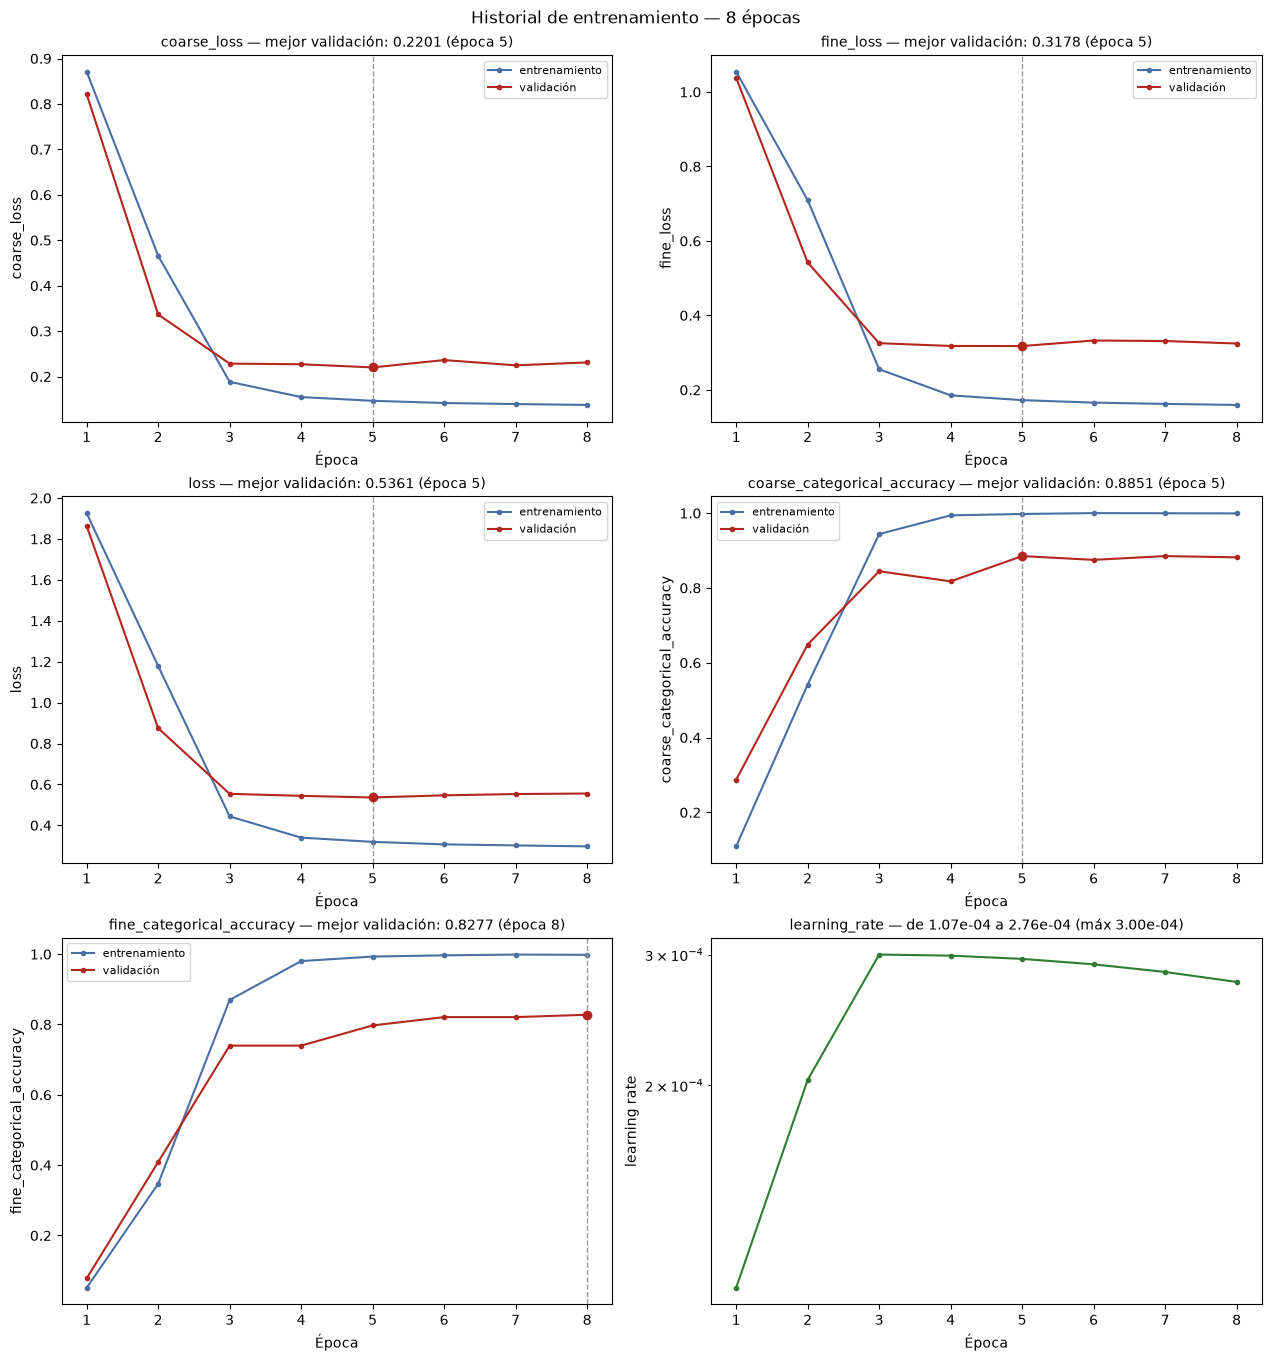

In [17]:
historial = plot_history(history)

In [18]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def collect_predictions(model, dataset, head_names=("fine", "coarse")):
    """Recorre el dataset una vez y devuelve {head: (y_true, y_pred)} como enteros."""
    y_true = {name: [] for name in head_names}
    y_pred = {name: [] for name in head_names}

    for images, labels in dataset:
        labels = labels if isinstance(labels, (tuple, list)) else (labels,)
        outputs = model.predict(images, verbose=0)
        outputs = outputs if isinstance(outputs, (tuple, list)) else (outputs,)

        for name, true, pred in zip(head_names, labels, outputs):
            true = np.asarray(true)
            y_true[name].append(np.argmax(true, axis=-1) if true.ndim > 1 else true)
            y_pred[name].append(np.argmax(pred, axis=-1))

    return {
        name: (np.concatenate(y_true[name]), np.concatenate(y_pred[name]))
        for name in head_names
    }


def evaluate_model(
    model, dataset, average: str = "macro", head_names=("fine", "coarse")
):
    predicciones = collect_predictions(model, dataset, head_names=head_names)

    filas = []
    for name in head_names:
        true, pred = predicciones[name]

        filas.append(
            {
                "head": name,
                "classes": len(np.unique(true)),
                "images": len(true),
                "accuracy": accuracy_score(true, pred),
                "precision": precision_score(
                    true, pred, average=average, zero_division=0
                ),
                "recall": recall_score(true, pred, average=average, zero_division=0),
                "f1": f1_score(true, pred, average=average, zero_division=0),
            }
        )

    return pd.DataFrame(filas).set_index("head")

In [19]:
RUTA_MODELO = pathlib.Path(f"../models/reto-03-{model.name}.keras")

del model

trained_model = keras.models.load_model(RUTA_MODELO)

In [20]:
df = evaluate_model(trained_model, test_ds)
df.head(10)

,classes,images,accuracy,precision,recall,f1
head,,,,,,
fine,81,2485,0.834205,0.858512,0.833646,0.834318
coarse,43,2485,0.900201,0.885698,0.836262,0.847635


In [21]:
from sklearn.metrics import confusion_matrix

NOMBRES_CLASES = {
    "fine": ("class_id", "class_name"),
    "coarse": ("coarse_class_id", "coarse_class_name"),
}


def plot_confusion_matrix(
    model,
    dataset,
    classes: pd.DataFrame = None,
    head_names=("fine", "coarse"),
    normalize: bool = True,
    annotate: bool = None,
    cmap: str = "Blues",
    figsize_scale: float = 0.28,
    predictions=None,
):
    """Dibuja la matriz de confusión de cada cabeza y devuelve {head: DataFrame}."""
    if predictions is None:
        predictions = collect_predictions(model, dataset, head_names=head_names)

    matrices = {}
    for name in head_names:
        true, pred = predictions[name]
        etiquetas = np.union1d(np.unique(true), np.unique(pred))

        matriz = confusion_matrix(true, pred, labels=etiquetas)
        if normalize:
            totales = matriz.sum(axis=1, keepdims=True)
            matriz = np.divide(
                matriz,
                totales,
                out=np.zeros(matriz.shape, dtype="float64"),
                where=totales != 0,
            )

        nombres = [int(i) for i in etiquetas]
        if classes is not None and name in NOMBRES_CLASES:
            id_column, name_column = NOMBRES_CLASES[name]
            mapa = dict(zip(classes[id_column], classes[name_column]))
            nombres = [mapa.get(int(i), int(i)) for i in etiquetas]

        df = pd.DataFrame(matriz, index=nombres, columns=nombres)
        df.index.name = "real"
        df.columns.name = "predicho"
        matrices[name] = df

        lado = max(5.0, len(etiquetas) * figsize_scale)
        fig, ax = plt.subplots(figsize=(lado, lado), layout="constrained")

        imagen = ax.imshow(
            matriz, cmap=cmap, vmin=0, vmax=1 if normalize else matriz.max()
        )
        fig.colorbar(imagen, ax=ax, shrink=0.8)

        ax.set_xticks(range(len(nombres)), nombres, rotation=90, fontsize=7)
        ax.set_yticks(range(len(nombres)), nombres, fontsize=7)
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")
        ax.grid(visible=False)

        mostrar = len(etiquetas) <= 20 if annotate is None else annotate
        if mostrar:
            umbral = matriz.max() / 2.0
            for i in range(matriz.shape[0]):
                for j in range(matriz.shape[1]):
                    valor = matriz[i, j]
                    ax.text(
                        j,
                        i,
                        f"{valor:.2f}" if normalize else f"{int(valor)}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white" if valor > umbral else "#333333",
                    )

        aciertos = np.trace(confusion_matrix(true, pred, labels=etiquetas))
        titulo = "normalizada por fila" if normalize else "conteos"
        ax.set_title(
            f"Matriz de confusión — clase {name} ({len(etiquetas)} clases, {titulo})\n"
            f"{aciertos} de {len(true)} correctas"
        )
        plt.show()

    return matrices

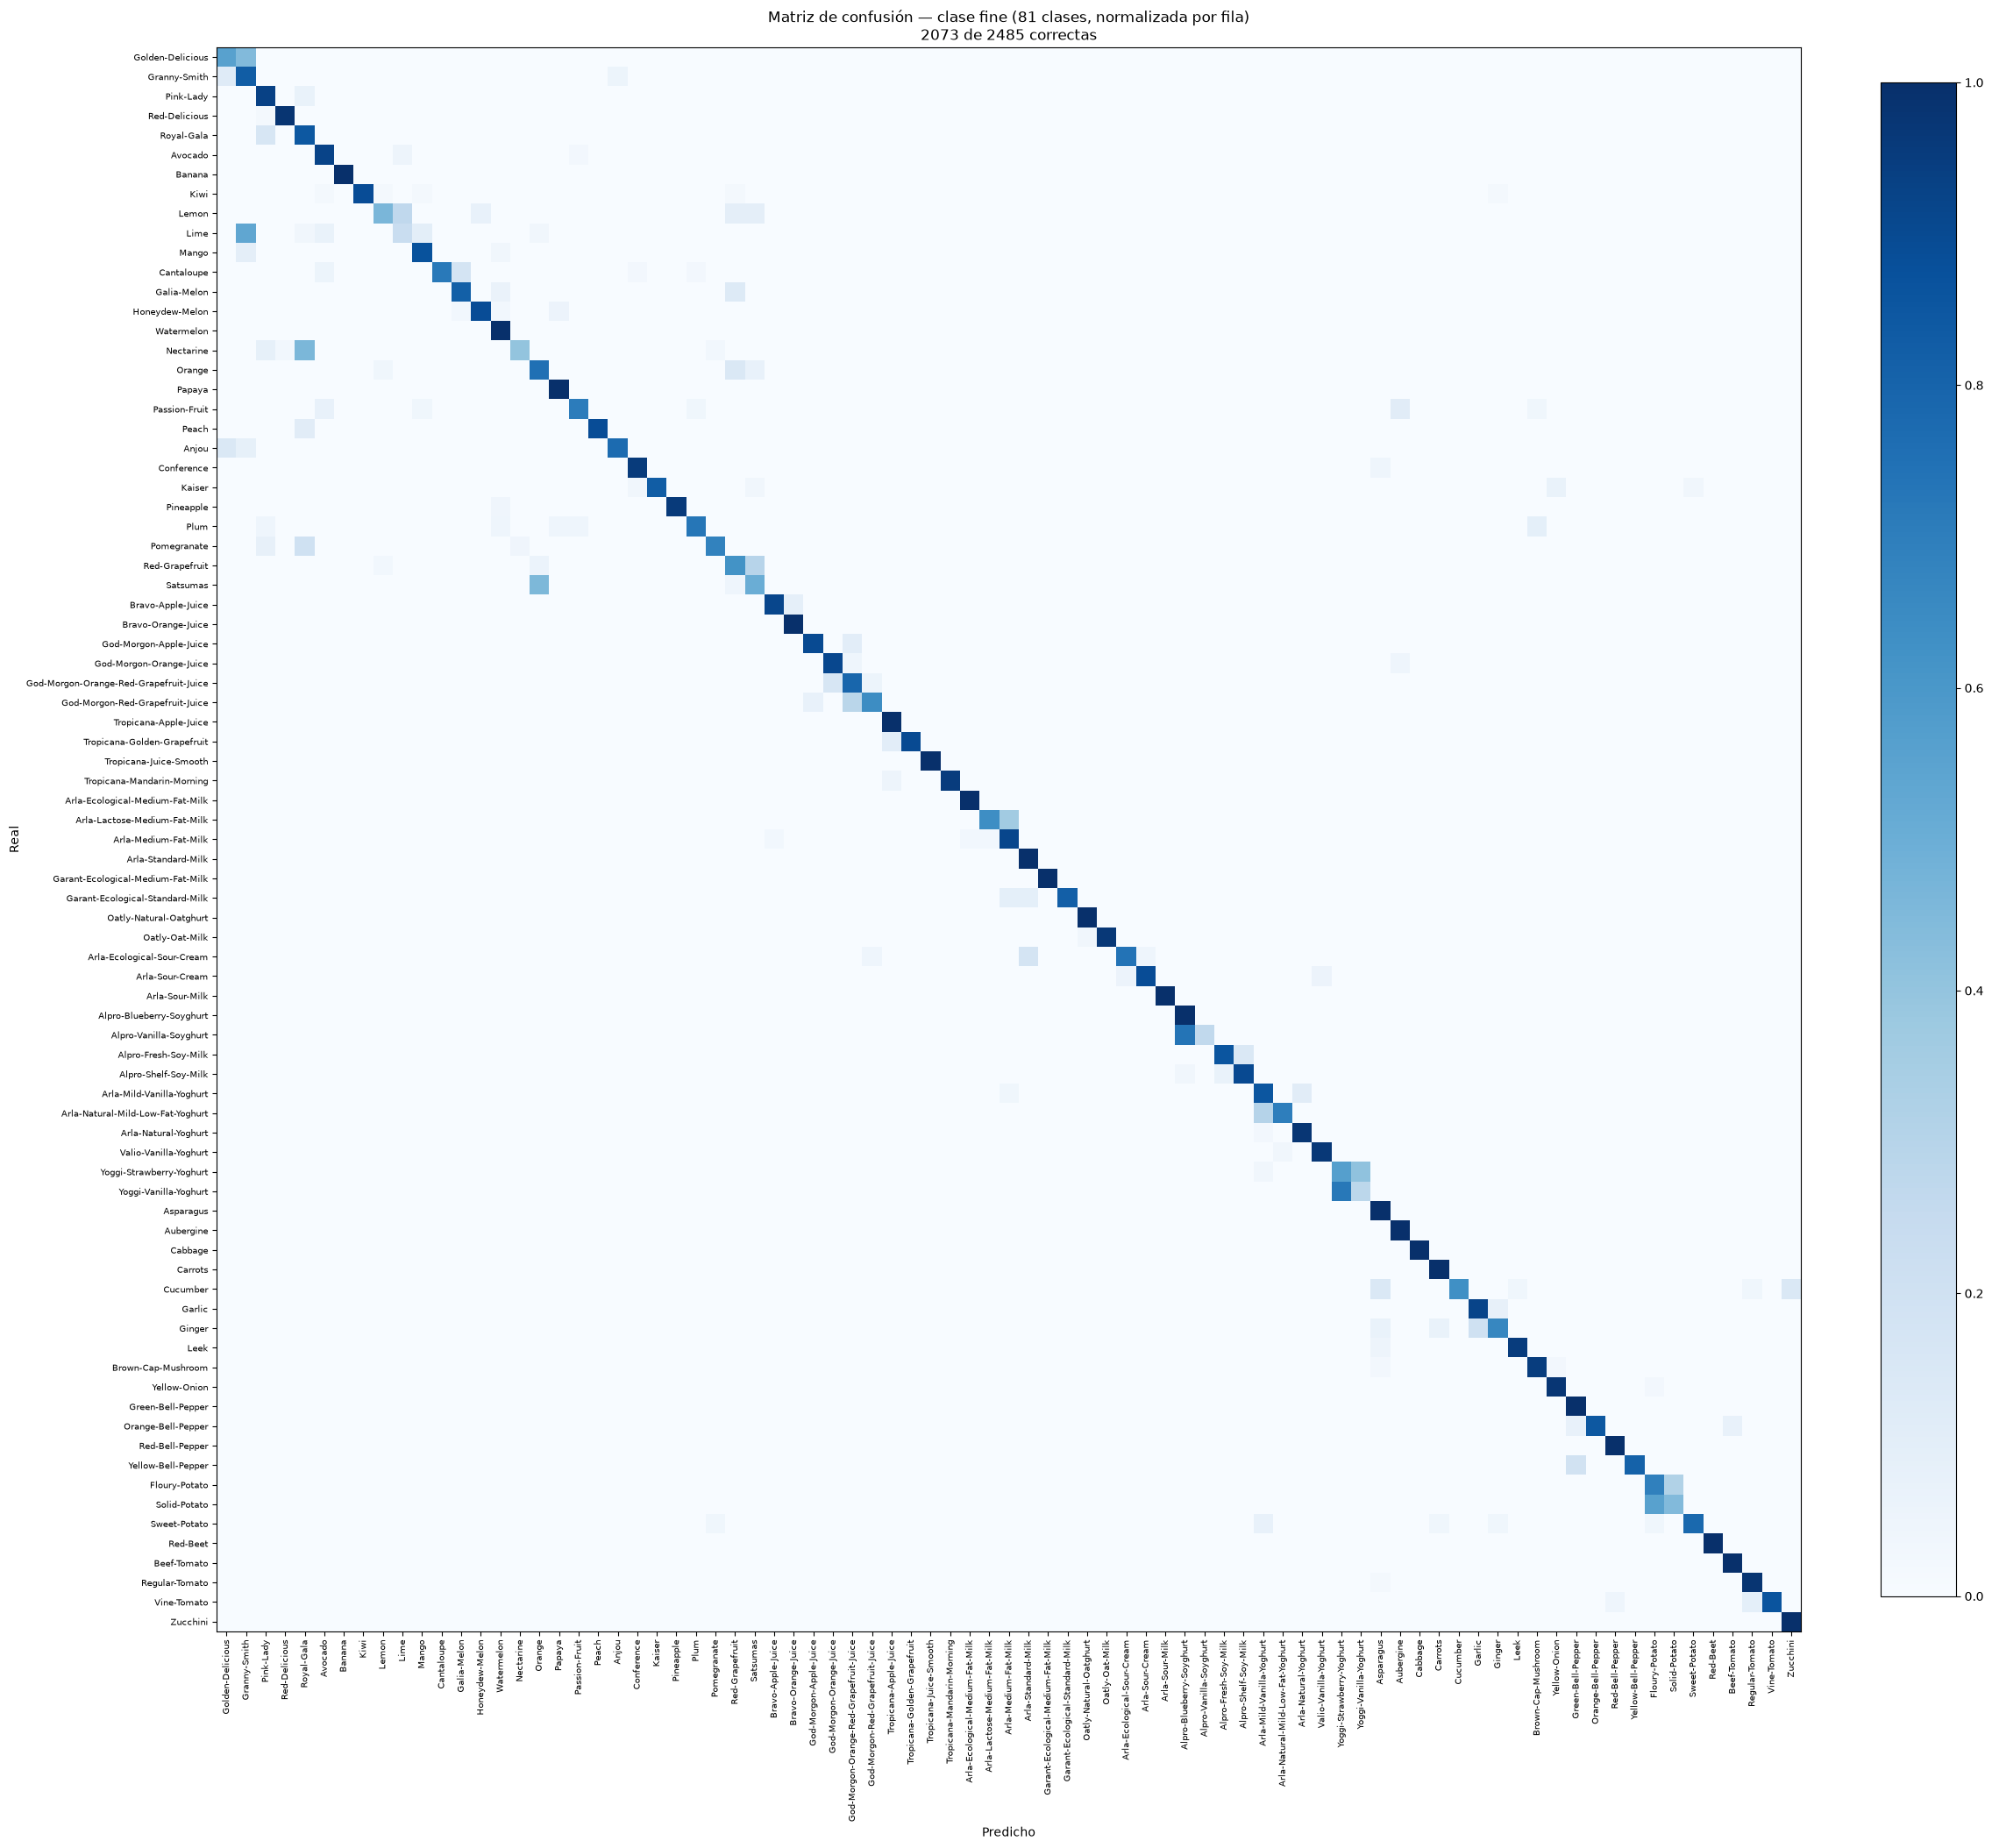

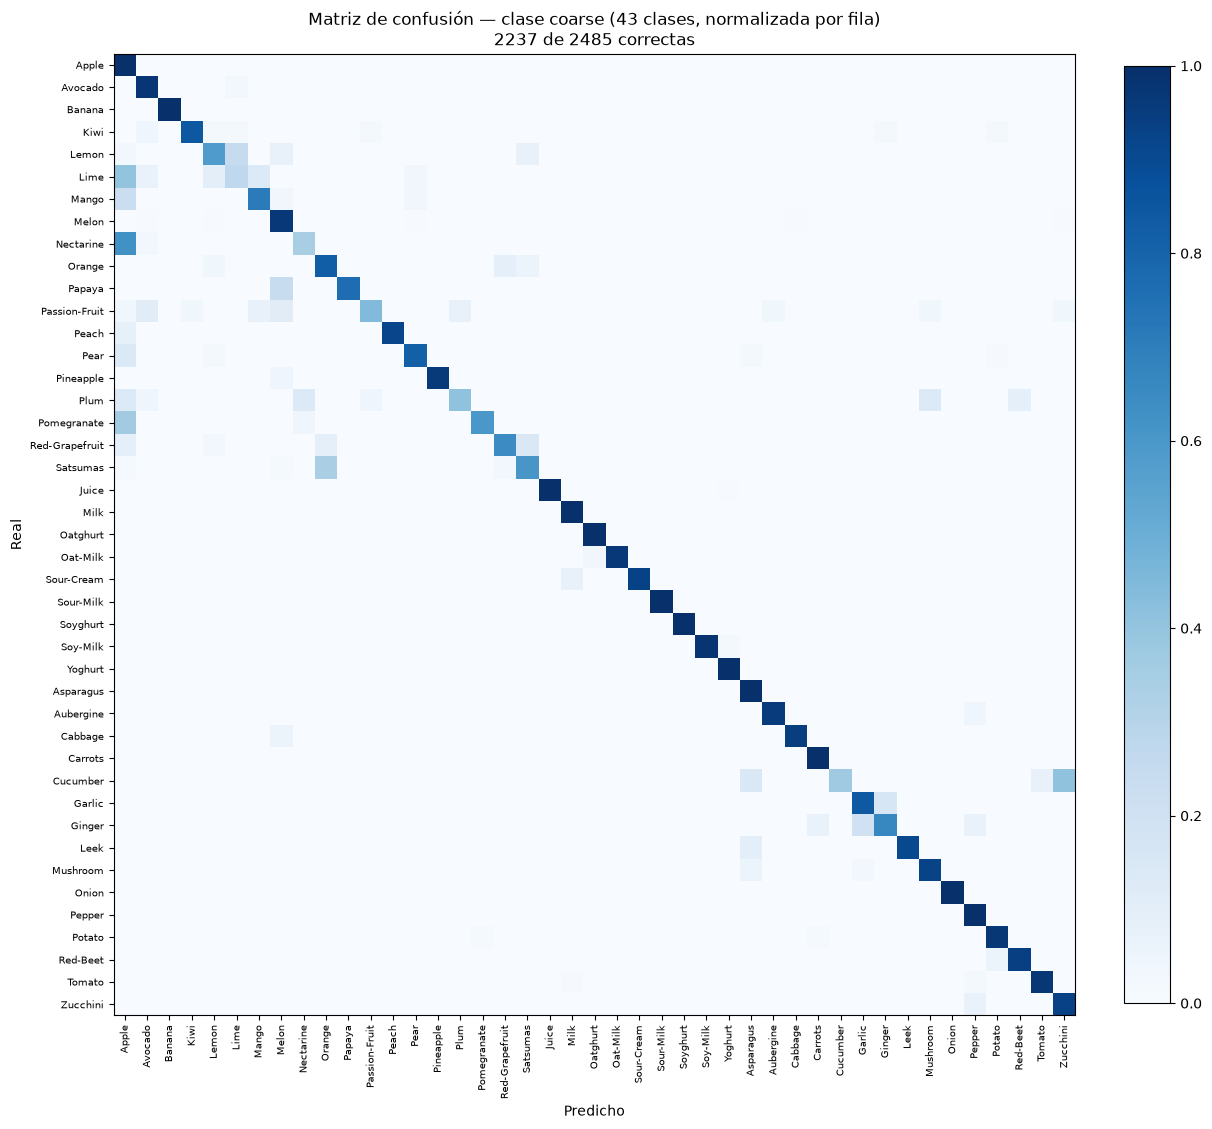

In [22]:
matrices = plot_confusion_matrix(trained_model, test_ds, classes=classes)

In [23]:
def plot_predictions(
    model,
    source,
    indices=None,
    n: int = 16,
    cols: int = 4,
    classes: pd.DataFrame = None,
    preprocess=preprocess,
    figsize_scale: float = 3.0,
    seed: int = None,
):
    def etiquetas(ids):
        ids = np.asarray(ids)

        return np.argmax(ids, axis=-1) if ids.ndim > 1 else np.ravel(ids)

    if isinstance(source, tuple):
        images, fine_ids, coarse_ids = source
        images = np.asarray(images)
        fine_ids, coarse_ids = etiquetas(fine_ids), etiquetas(coarse_ids)
        titulo = "Predicciones"
    else:
        rng = np.random.default_rng(seed)
        total = len(source)
        if indices is None:
            indices = rng.permutation(total)[: min(n, total)]
        indices = np.ravel(indices).astype(int)

        muestras = [source[int(i)] for i in indices]
        images = np.stack([m[0] for m in muestras])
        fine_ids = etiquetas([m[1] for m in muestras])
        coarse_ids = etiquetas([m[2] for m in muestras])
        titulo = f"Predicciones sobre {len(indices)} imágenes de {total}"

    n = min(n, len(images))
    images, fine_ids, coarse_ids = images[:n], fine_ids[:n], coarse_ids[:n]
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))

    entradas = images if preprocess is None else preprocess(images)
    fine_probs, coarse_probs = model.predict(entradas, verbose=0)

    fine_names, coarse_names = {}, {}
    if classes is not None:
        fine_names = dict(zip(classes.class_id, classes.class_name))
        coarse_names = dict(zip(classes.coarse_class_id, classes.coarse_class_name))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale, rows * figsize_scale * 1.3),
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    aciertos = 0
    for i, ax in enumerate(axes[:n]):
        fine_pred, coarse_pred = int(np.argmax(fine_probs[i])), int(
            np.argmax(coarse_probs[i])
        )
        fine_true, coarse_true = int(fine_ids[i]), int(coarse_ids[i])
        acierto = fine_pred == fine_true
        aciertos += acierto

        ax.imshow(images[i].astype("uint8"))
        ax.set_title(
            f"{fine_names.get(fine_pred, fine_pred)} {fine_probs[i][fine_pred]:.0%}\n"
            f"({coarse_names.get(coarse_pred, coarse_pred)} {coarse_probs[i][coarse_pred]:.0%})\n"
            f"real: {fine_names.get(fine_true, fine_true)}"
            f" ({coarse_names.get(coarse_true, coarse_true)})",
            fontsize=9,
            color="#1B7F3B" if acierto else "#B3261E",
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"{titulo} — {aciertos} de {n} correctas en la clase fina")
    plt.show()

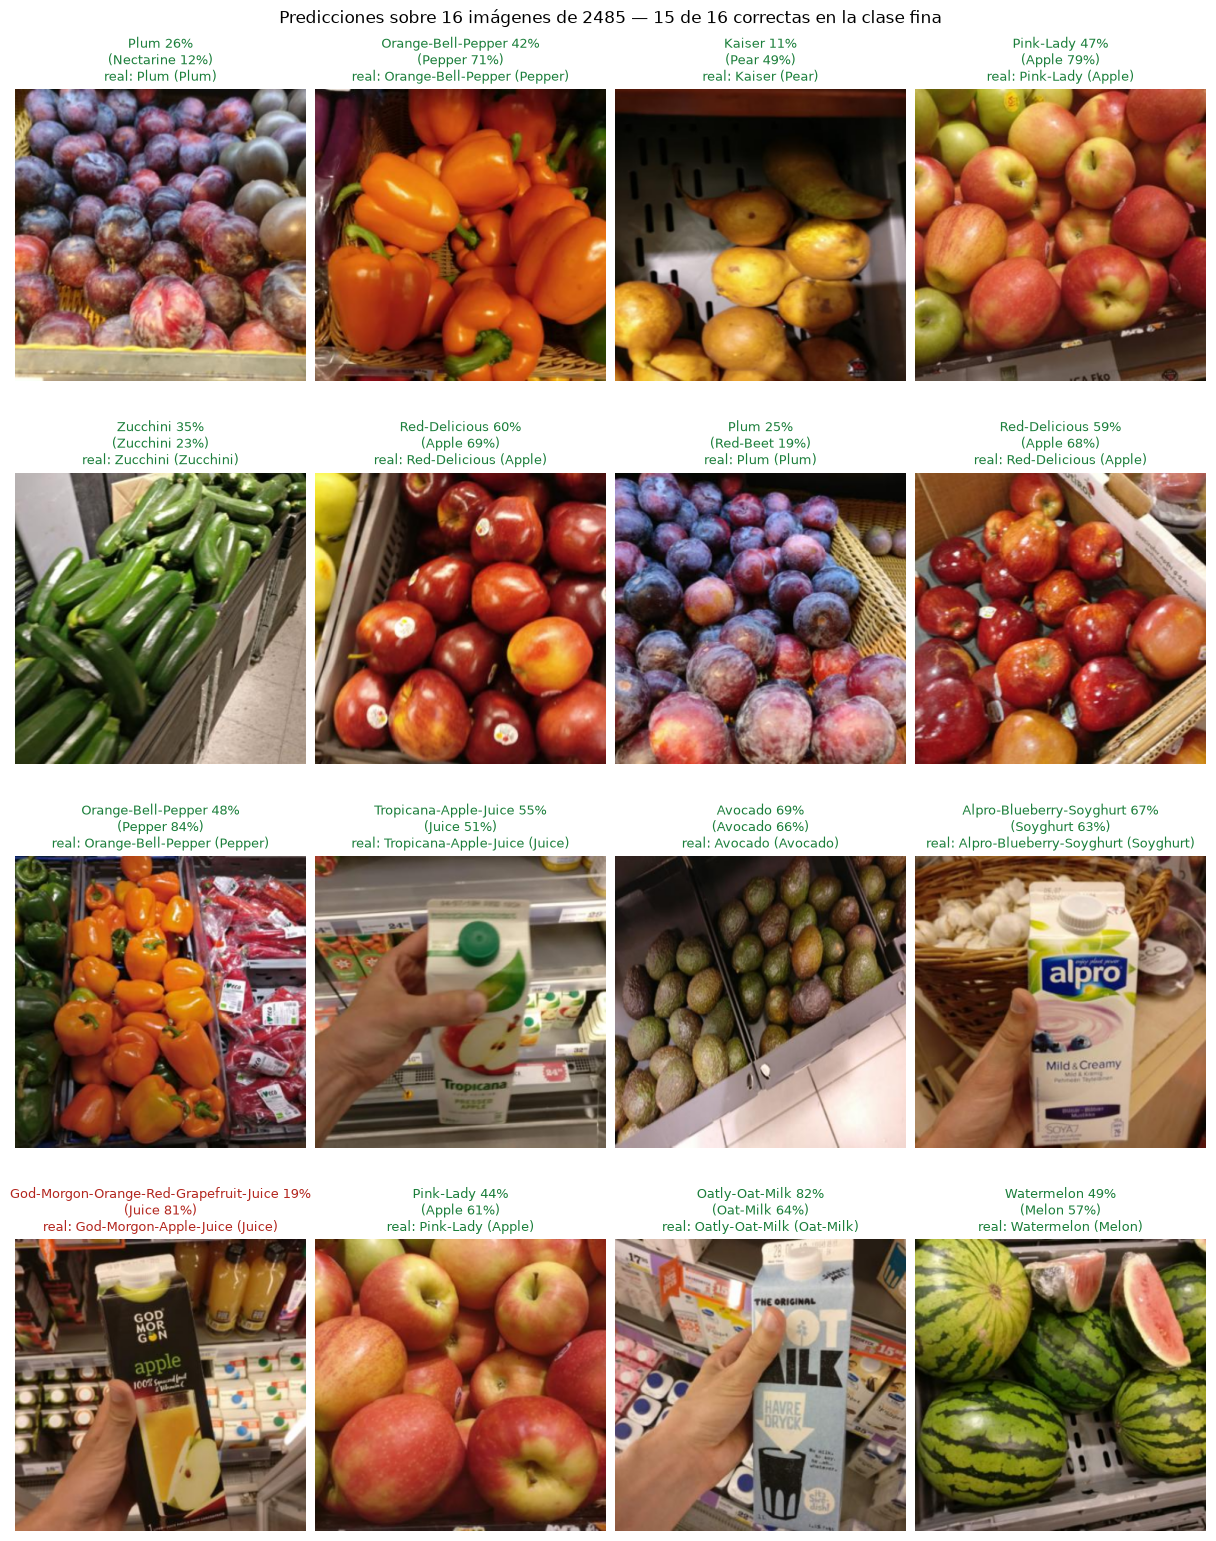

In [24]:
plot_predictions(trained_model, test_seq, classes=classes)